# **Extracting Dataset From Google Drive**

This section downloads the dataset from the Google Drive link. You do not need to manually put it in the runtime environment.

In [1]:
!pip install -q gdown
import gdown

file_id = "1Tng1snYG0P9NUsSFy6--whhm0KhNJ46g"
url = f"https://drive.google.com/uc?id={file_id}"
output = "Dataset.zip"

gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1Tng1snYG0P9NUsSFy6--whhm0KhNJ46g
From (redirected): https://drive.google.com/uc?id=1Tng1snYG0P9NUsSFy6--whhm0KhNJ46g&confirm=t&uuid=31f78092-1d29-4171-af99-60ed4abb5551
To: /content/Dataset.zip
100%|██████████| 2.65G/2.65G [00:43<00:00, 61.0MB/s]


'Dataset.zip'

Here, Downloaded Dataset is unzipped.

In [2]:
import zipfile
zip_path = '/content/Dataset.zip'
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset unzipped")

Dataset unzipped


# **Custom CNN**

In this section a custom CNN is implemented.

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset, random_split
import pathlib
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import gc
from sklearn.model_selection import train_test_split
import torchvision.transforms.v2 as v2
from sklearn.metrics import classification_report
import warnings
import time
warnings.filterwarnings("ignore")

**count_classes_in_subset** function is a helper function that count classes from the dataset.

**evaluate_loss** function calculates the loss. I used it for validation loss in order to make the code cleaner.

In [ ]:
def count_classes_in_subset(subset):
    all_targets = []

    for idx in subset.indices:
        dataset_id = 0
        offset = 0

        for ds in subset.dataset.datasets:
            if idx < offset + len(ds):
                sample_target = ds.targets[idx - offset]
                all_targets.append(sample_target)
                break
            offset += len(ds)

    class_counts = Counter(all_targets)

    class_names = subset.dataset.datasets[0].classes

    for class_idx, count in sorted(class_counts.items()):
        print(f"{class_names[class_idx]:<20} → {count} samples")

    return class_counts



def evaluate_loss(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

    avg_test_accuracy = 100 * correct / total_samples

    avg_test_loss = total_loss / total_samples
    return avg_test_loss, avg_test_accuracy


**Dataset Prepration**

Here the dataset is prepared for training.

`torch.multiprocessing.set_sharing_strategy('file_system')`

This makes parallel thread execution faster.

Since the dataset is shuffled before dataloader loads the dataset, i used pre-defined seed to make training process same for every excecution:

`seed = 42`
`torch.manual_seed(seed)`

There are two transforms defined:

```python
original_transforms = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transforms_combined = v2.Compose([
        v2.RandomAffine(
            degrees=30,
            translate=(0.1, 0.1),
            scale=(1.1, 1.4),
            shear=10,
            fill=0
        ),

        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.2),

        v2.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05
        ),

        v2.CenterCrop(100),
        v2.Resize((100, 100)),

        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),

        v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])

```
First one only changes images size to 100x100 and makes it tensor.

Second one applies data agumentation, resizes the image to 100x100 and makes it tensor.

I used torchvision.transforms.v2 for the second transformation beacuse it applies trasnformation using gpu and that makes faster execution per epoch.

The Dataset have Train and Test folders by default, but they are not split evenly across all classes.
```python
dataset_train = datasets.ImageFolder(root='Dataset/Training', transform=transforms_combined)
dataset_test = datasets.ImageFolder(root='Dataset/Test', transform=transforms_combined)

dataset = torch.utils.data.ConcatDataset([dataset_train, dataset_test])

all_samples = []
for ds in dataset.datasets:
    all_samples += ds.samples

targets = [sample[1] for sample in all_samples]
train_idx, temp_idx = train_test_split(range(len(dataset)), test_size=0.3, stratify=targets, random_state=42)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=42)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)
```

Here, first i merged two folders into one and split it evenly as 70% train, 15% test and 15% validation sets using train_test_split from sklearn library.

At the end total number of samples are printed for each set.

In [ ]:
torch.multiprocessing.set_sharing_strategy('file_system')

np.set_printoptions(precision=3)
seed = 42
torch.manual_seed(seed)


original_transforms = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transforms_combined = v2.Compose([
        v2.RandomAffine(
            degrees=30,
            translate=(0.1, 0.1),
            scale=(1.1, 1.4),
            shear=10,
            fill=0
        ),

        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.2),

        v2.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05
        ),

        v2.CenterCrop(100),
        v2.Resize((100, 100)),

        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),

        v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])

dataset_train = datasets.ImageFolder(root='Dataset/Training', transform=transforms_combined)
dataset_test = datasets.ImageFolder(root='Dataset/Test', transform=transforms_combined)

dataset = torch.utils.data.ConcatDataset([dataset_train, dataset_test])

all_samples = []
for ds in dataset.datasets:
    all_samples += ds.samples

targets = [sample[1] for sample in all_samples]
train_idx, temp_idx = train_test_split(range(len(dataset)), test_size=0.3, stratify=targets, random_state=42)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=42)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True, pin_memory=True,num_workers=12)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False, pin_memory=True,num_workers=12)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False, pin_memory=True,num_workers=12)

print("Number of classes:", len(dataset_train.classes))
print("Number of training samples:", len(train_loader.dataset))
print("Number of test samples:", len(val_loader.dataset))
print("Number of validation samples:", len(test_loader.dataset))


Number of classes: 226
Number of training samples: 123796
Number of test samples: 26528
Number of validation samples: 26528


In this section, the custom CNNs' architecture is defined:
```
Image (100x100x3) -> Conv2d1 (100x100x16) -> Relu -> maxpooling (50x50x16) -> Conv2d2 (50x50x32) -> Relu -> maxpooling (25x25x32)-> Conv2d3 (25x25x64) -> Relu -> maxpooling (12x12x64) -> flatten (9216 x 1) -> fc1 (1024) -> dropout -> fc2 (512) -> dropout -> fc3 (226)
```

In [ ]:
class CNN(nn.Module):
    def __init__(self,num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 12 * 12, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)

        return x

**Model Setup and Optimization in PyTorch**

```python
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
```
Select device: use Apple Silicon GPU if available, otherwise CUDA GPU or CPU. It checks for apple silicon since i trained on my macbook as well.

```python
model = CNN(num_classes=len(dataset_train.classes)).to(device)
```
Initialize the CNN model and move it to the selected device

```python
criterion = nn.CrossEntropyLoss()
```
Set the loss function to CrossEntropyLoss, commonly used for multi class classification tasks
```python
optimizer = torch.optim.Adam(model.parameters(), weight_decay=1e-4, lr=0.001)
```
Use the Adam optimizer with L2 regularization (weight decay) and a learning rate of 0.001
```python
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
```
Define a learning rate scheduler that reduces LR when validation loss plateaus

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

model = CNN(num_classes=len(dataset_train.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), weight_decay=1e-4 ,lr=0.001)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

**Model Training Loop Description**

This section performs the training of a custom CNN model over multiple epochs with the following logic:

- **Initialization:**
  - Lists are created to store training and validation losses and accuracies over epochs.
  - A counter is set up to track early stopping conditions.
  - The previous best validation loss is initialized to infinity.
  - Training time is measured using `time.time()`.

- **Training Loop:**
  - The loop runs up to 500 epochs.
  - For each epoch:
    - The model is set to training mode.
    - Gradients are cleared at the start of each batch.
    - Forward pass is performed to get predictions.
    - Loss is calculated using the criterion and backpropagated.
    - The optimizer updates the model parameters.
    - Predictions are compared to true labels to calculate training accuracy.
    - Running loss is accumulated for average epoch loss.

- **Validation:**
  - After each epoch, validation loss and accuracy are computed using a separate `evaluate_loss` function.
  - A learning rate scheduler (`ReduceLROnPlateau`) is applied to reduce learning rate if validation loss doesn't improve.
  - If the learning rate is updated, it is printed.

- **Metrics Tracking:**
  - Training and validation losses and accuracies are stored.
  - Epoch metrics are printed after each epoch.

- **Model Saving and Early Stopping:**
  - If the validation loss improves, the model is saved as `plant_model.pth`.
  - If it does not improve for more than 5 consecutive epochs, early stopping is triggered to prevent overfitting.

- **Training Time:**
  - After training completes or early stopping occurs, total training time is printed.


In [ ]:
correct_train = 0
train_accuracies = []
train_loss = []
val_accuracys = []
val_losses = []
stop_training_counter = 0
total = 0
print("Training the model...")
print("----------------------------------------------------------")
prev_loss = float('inf')
prev_val_loss = float('inf')
startTime = time.time()
for epoch in range(500):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)

    epoch_loss= running_loss / total
    train_loss.append(epoch_loss)
    val_loss, val_accuracy = evaluate_loss(model, val_loader, criterion, device)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"LR scheduler kicked in LR changed from {old_lr:.6f} → {new_lr:.6f}")

    train_acc = correct_train / total
    train_accuracies.append(train_acc*100)
    val_losses.append(val_loss)
    val_accuracys.append(val_accuracy)

    print(f"Epoch {epoch+1}")
    print(f"Epoch [{epoch+1}], Train Accuracy: {train_acc*100}%")
    print(f"Epoch [{epoch + 1}], Train Loss: {epoch_loss}")
    print(f"Epoch [{epoch + 1}], Validation Loss: {val_loss}")
    print(f"Epoch [{epoch + 1}], Validation Accuracy: {val_accuracy}")

    gc.collect()

    if val_loss < prev_val_loss:
        torch.save(model, 'plant_model.pth')
        print("Model saved as plant_model.pth")
        prev_val_loss = val_loss
        stop_training_counter = 0
    else:
        stop_training_counter += 1
        if stop_training_counter > 5:
            print("Early stopping!!!")
            break

    print("↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓")
endTime = time.time()
customCNN_time = endTime - startTime
print(f"Total training time for custom CNN: {customCNN_time} seconds")


Training the model...
----------------------------------------------------------


Epoch 1: 100%|██████████| 242/242 [02:50<00:00,  1.42it/s]


Epoch 1
Epoch [1], Train Accuracy: 26.898284274128404%
Epoch [1], Train Loss: 3.013672635730062
Epoch [1], Validation Loss: 2.0884087689679265
Epoch [1], Validation Accuracy: 44.39083232810615
Model saved as plant_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 2: 100%|██████████| 242/242 [02:50<00:00,  1.42it/s]


Epoch 2
Epoch [2], Train Accuracy: 45.508740185466415%
Epoch [2], Train Loss: 2.0523985878917186
Epoch [2], Validation Loss: 1.7204932285016639
Epoch [2], Validation Accuracy: 53.75829312424608
Model saved as plant_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


...

LR scheduler kicked in LR changed from 0.000063 → 0.000031
Epoch 94
Epoch [94], Train Accuracy: 84.94862515751721%
Epoch [94], Train Loss: 0.5484345082709152
Epoch [94], Validation Loss: 0.4831064907863143
Epoch [94], Validation Accuracy: 87.34921592279855
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 95: 100%|██████████| 242/242 [02:46<00:00,  1.46it/s]


Epoch 95
Epoch [95], Train Accuracy: 84.99789977059032%
Epoch [95], Train Loss: 0.5447814971061241
Epoch [95], Validation Loss: 0.48361512950303615
Epoch [95], Validation Accuracy: 87.23612786489747
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 96: 100%|██████████| 242/242 [02:45<00:00,  1.46it/s]


Epoch 96
Epoch [96], Train Accuracy: 85.12229797408641%
Epoch [96], Train Loss: 0.5448311538764697
Epoch [96], Validation Loss: 0.4858618023455934
Epoch [96], Validation Accuracy: 86.87801568154403
Early stopping!!!
Total training time for custom CNN: 19954.693927526474 seconds


**Visualizing Training and Validation Metrics**

This section plots the training progress over time using Matplotlib:

- **Epoch Range:**
  - The `epochs` variable is defined based on the number of recorded training loss values to align the x-axis in plots.

- **Loss Plot:**
  - A line plot is created to visualize the loss values for both training and validation over the epochs.
  - The plot includes:
    - A title: "Training Loss Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Loss"
    - A legend to distinguish between training and validation losses
    - A grid for readability
    - `tight_layout()` ensures proper spacing of plot elements

- **Accuracy Plot:**
  - A similar line plot is created to compare training and validation accuracy across epochs.
  - It includes:
    - A title: "Validation Accuracy Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Accuracy"
    - A legend to differentiate accuracy metrics
    - A grid and layout adjustment for clarity

These visualizations used fro monitoring model performance, detecting overfitting, and evaluating the effectiveness of training over time.


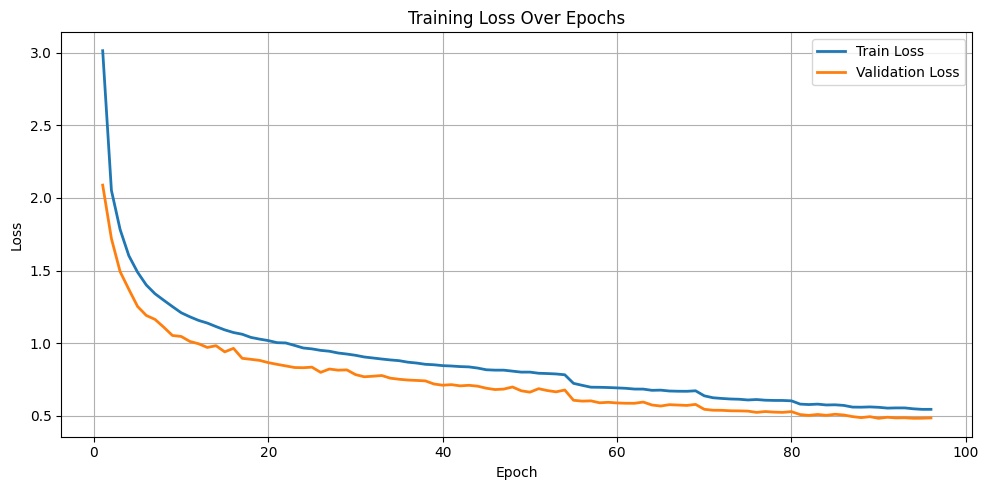

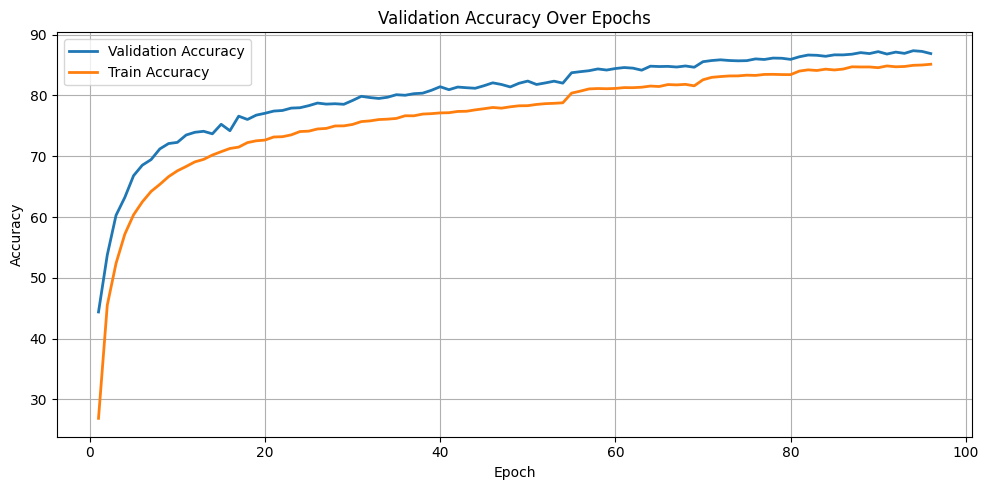

In [ ]:
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Train Loss', linewidth=2)
plt.plot(epochs, val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, val_accuracys, label='Validation Accuracy', linewidth=2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Model Evaluation on Test Data**

This section evaluates the trained CNN model on unseen test data:

- **Evaluation Mode:**
  - The model is set to evaluation mode using `model.eval()` to disable dropout and batch normalization updates.

- **Metric Initialization:**
  - Variables are initialized to track correct predictions, total samples, cumulative loss, and to collect all predicted and actual labels for later analysis.

- **Inference Loop:**
  - A loop iterates over the test data loader.
  - Gradients are disabled with `torch.no_grad()` to reduce memory usage and computation.
  - Inputs and labels are transferred to the selected device (CPU, CUDA, or MPS).
  - Predictions are made by passing inputs through the model.
  - The loss is calculated and accumulated.
  - Predictions are compared to true labels to count correct predictions.
  - Predicted and actual labels are stored for metrics computation.

- **Test Accuracy and Loss:**
  - After the loop, test accuracy is calculated as the ratio of correct predictions to total samples, and average test loss is computed.

- **Classification Report:**
  - The `classification_report` function from sklearn is used to compute:
    - **Weighted Precision**
    - **Weighted Recall**
    - **Weighted F1-Score**


At the end, test loss, test accuracy, and weighted performance metrics are printed for model evaluation.


In [ ]:
model.eval()
correct = 0
total = 0
total_samples = 0
test_loss = 0.0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        test_loss += loss.item() * images.size(0)
        total_samples += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
avg_test_loss = test_loss / total_samples

print(f"Test Loss: {avg_test_loss}")
print(f"Test Accuracy: {test_accuracy}%")

report = classification_report(all_labels, all_preds, output_dict=True)
custom_precision = report['weighted avg']['precision']
custom_recall = report['weighted avg']['recall']
custom_f1_score = report['weighted avg']['f1-score']
print(f"Weighted Precision for custom CNN: {custom_precision}")
print(f"Weighted Recall for custom CNN:    {custom_recall}")
print(f"Weighted F1-Score for custom CNN:  {custom_f1_score}")


Test Loss: 0.4921536098343328
Test Accuracy: 86.81770205066346%
Weighted Precision for custom CNN: 0.8649625405732468
Weighted Recall for custom CNN:    0.8681770205066345
Weighted F1-Score for custom CNN:  0.8639099093726128


# **Tranfer Learning**

In this section, four models are trained using transfer learning.

## *VGG16*

In [ ]:
from torchvision import models, transforms, datasets
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import warnings
import time
warnings.filterwarnings("ignore")

**Dataset Preparation and DataLoader Setup**

This section prepares the dataset and splits it into training, validation, and test sets with stratified sampling:

- **Transformations:**
  - A transformation pipeline is defined using `transforms.Compose`:
    - `Resize`: Resizes all images to 224×224 pixels.
    - `ToTensor`: Converts images to PyTorch tensors.
    - `Normalize`: Normalizes pixel values to the range [-1, 1] using mean and standard deviation values of 0.5 per channel (RGB).

- **Dataset Loading:**
  - Two image datasets are loaded using `datasets.ImageFolder`, one for training and one for testing, both applying the same transform.
  - These two datasets are combined into a single dataset using `ConcatDataset`.

- **Stratified Splitting:**
  - All image-label pairs (`samples`) are extracted from both datasets.
  - Class labels (`targets`) are collected from these samples.
  - A stratified split ensures class distribution is preserved across subsets:
    - 70% of the data is used for training.
    - The remaining 30% is further split evenly into validation and test sets.
  - `train_test_split` from scikit-learn is used, first to create the training set, and then to split the remaining into validation and test.

- **Subset Creation:**
  - `Subset` objects are created from the full dataset using the calculated indices.

- **DataLoader Setup:**
  - `DataLoader` objects are created for each subset:
    - `train_loader` uses `shuffle=True` for randomness in training.
    - `val_loader` and `test_loader` use `shuffle=False` to preserve order.
    - `batch_size=512` and `num_workers=12` are set for efficient loading.
    - `pin_memory=True` speeds up data transfer to CUDA if available.

Finally, the end, it prints the number of classes and the size of each dataset split to confirm successful setup.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset_train = datasets.ImageFolder('Dataset/Training', transform=transform)
dataset_test = datasets.ImageFolder("Dataset/Test", transform=transform)

dataset = torch.utils.data.ConcatDataset([dataset_train, dataset_test])

all_samples = []
for ds in dataset.datasets:
    all_samples += ds.samples

targets = [sample[1] for sample in all_samples]
train_idx, temp_idx = train_test_split(range(len(dataset)), test_size=0.3, stratify=targets, random_state=42)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=42)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True, pin_memory=True,num_workers=12)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False, pin_memory=True,num_workers=12)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False, pin_memory=True,num_workers=12)

print("Number of classes:", len(dataset_train.classes))
print("Number of training samples:", len(train_loader.dataset))
print("Number of test samples:", len(test_loader.dataset))
print("Number of validation samples:", len(val_loader.dataset))

Number of classes: 226
Number of training samples: 123796
Number of test samples: 26528
Number of validation samples: 26528


**Transfer Learning with VGG16**

This section defines a transfer learning model using a pre-trained VGG16 architecture from `torchvision.models`:

- **Base Model:**
  - The VGG16 model is loaded with `pretrained=True`, which imports weights learned from training on the ImageNet dataset.
  - All convolutional layers are frozen by setting `requires_grad = False` to prevent their weights from being updated during training. This leverages pre-learned visual features and reduces training time.

- **Classifier Replacement:**
  - The original classifier (fully connected layers) is replaced with a custom `nn.Sequential` block:
    - `Linear(25088 -> 4096)`: The input size matches the output of the convolutional base.
    - `ReLU()`: Activation function to introduce non-linearity.
    - `Dropout(0.5)`: Regularization to prevent overfitting.
    - `Linear(4096 -> 1024)`: Further dimensionality reduction.
    - `ReLU()` and `Dropout(0.3)`: Additional activation and regularization.
    - `Linear(1024 -> num_classes)`: Final output layer maps to the number of target classes.


In [ ]:
model = models.vgg16(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, len(dataset_train.classes))
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 216MB/s]


**Model Device Setup and Optimization Configuration**

- **Model Deployment:**
  - The model is moved to the selected device with `model.to(device)` to ensure compatibility during training and inference.

- **Loss Function:**
  - `CrossEntropyLoss` is used as the criterion, which is suitable for multi-class classification tasks.

- **Optimizer:**
  - The Adam optimizer is selected for its adaptive learning rate capabilities.
  - A learning rate of `0.0005` is used.
  - `weight_decay=1e-4` applies L2 regularization to prevent overfitting by penalizing large weights.


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

**Training Loop for VGG16 Transfer Learning Model**

This section trains the modified VGG16 model for 20 epochs with early stopping and tracks performance metrics throughout:

- **Metric Tracking:**
  - Four lists are used to store training and validation loss and accuracy for each epoch.
  - A variable `best_val_loss` keeps track of the lowest validation loss to identify the best-performing model.
  - `stop_training_counter` is used to implement early stopping when the validation loss does not improve.

- **Training Phase (Per Epoch):**
  - The model is set to training mode.
  - Each batch of images and labels is:
    - Moved to the appropriate device (MPS, CUDA, or CPU).
    - Forwarded through the model to generate predictions.
    - Compared to the true labels using the loss function (`CrossEntropyLoss`).
    - Backpropagated through the model to compute gradients.
    - Updated using the Adam optimizer.
  - The cumulative loss and number of correct predictions are tracked to calculate training accuracy and average loss for the epoch.

- **Validation Phase (Per Epoch):**
  - The model is switched to evaluation mode with gradient tracking disabled.
  - A forward pass is performed on the validation set.
  - Validation loss and accuracy are calculated across all batches.

- **Model Checkpointing and Early Stopping:**
  - If the validation loss improves, the model’s weights are saved to `"best_vgg16_model.pth"`.
  - If the validation loss does not improve for more than 3 consecutive epochs, training is stopped early to prevent overfitting.

- **Progress Output:**
  - After each epoch, training and validation loss/accuracy are printed.

- **Training Time Measurement:**
  - Total training time for the VGG16 model is measured and printed using `time.time()` before and after training.


In [ ]:
vgg_train_loss = []
vgg_val_loss = []
vgg_train_accs = []
vgg_val_accs = []
best_val_loss = float('inf')
stop_training_counter = 0

startTimen = time.time()

for epoch in range(20):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    vgg_train_loss.append(epoch_loss)
    vgg_train_accs.append(epoch_acc)

    model.eval()
    correct = 0.0
    val_loss_running = 0.0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_running += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_epoch_loss = val_loss_running / total
    val_epoch_acc = 100 * correct / total
    vgg_val_loss.append(val_epoch_loss)
    vgg_val_accs.append(val_epoch_acc)


    print(f"Epoch {epoch + 1}".format(epoch + 1, 50))
    print(f"Epoch [{epoch + 1}], Train Accuracy: {epoch_acc}%")
    print(f"Epoch [{epoch + 1}], Train Loss: {epoch_loss}")
    print(f"Epoch [{epoch + 1}], Validation Loss: {val_epoch_loss}")
    print(f"Epoch [{epoch + 1}], Validation Accuracy: {val_epoch_acc}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "best_vgg16_model.pth")
        print("Saved best_vgg16_model.pth")
    else:
        stop_training_counter += 1
        if stop_training_counter > 3:
            print("Early stopping...")
            break
    print("↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓")
endTimen = time.time()
VGG_time = endTimen - startTimen
print(f"Total training time for vgg: {VGG_time} seconds")

Epoch 1: 100%|██████████| 242/242 [05:48<00:00,  1.44s/it]


Epoch 1
Epoch [1], Train Accuracy: 83.05841868881062%
Epoch [1], Train Loss: 0.7146663583078201
Epoch [1], Validation Loss: 0.16834271173425405
Epoch [1], Validation Accuracy: 95.23145355850423
Saved best_vgg16_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 2: 100%|██████████| 242/242 [05:43<00:00,  1.42s/it]


Epoch 2
Epoch [2], Train Accuracy: 95.82377459691752%
Epoch [2], Train Loss: 0.14191579411253527
Epoch [2], Validation Loss: 0.12455614808097536
Epoch [2], Validation Accuracy: 96.37741254523522
Saved best_vgg16_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 3: 100%|██████████| 242/242 [05:43<00:00,  1.42s/it]


...

Epoch 6
Epoch [6], Train Accuracy: 97.72932889592556%
Epoch [6], Train Loss: 0.0726597562864172
Epoch [6], Validation Loss: 0.11422697417842465
Epoch [6], Validation Accuracy: 96.73175512665863
Saved best_vgg16_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 7: 100%|██████████| 242/242 [05:43<00:00,  1.42s/it]


Epoch 7
Epoch [7], Train Accuracy: 97.83191702478271%
Epoch [7], Train Loss: 0.06937767739881279
Epoch [7], Validation Loss: 0.12977237726221327
Epoch [7], Validation Accuracy: 96.32086851628468
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 8: 100%|██████████| 242/242 [05:44<00:00,  1.43s/it]


Epoch 8
Epoch [8], Train Accuracy: 97.89815502924165%
Epoch [8], Train Loss: 0.06523585616685242
Epoch [8], Validation Loss: 0.11907936833951671
Epoch [8], Validation Accuracy: 96.6450542822678
Early stopping...
Total training time for vgg: 3349.608226776123 seconds


**Visualizing Training and Validation Metrics**

This section plots the training progress over time using Matplotlib:

- **Epoch Range:**
  - The `epochs` variable is defined based on the number of recorded training loss values to align the x-axis in plots.

- **Loss Plot:**
  - A line plot is created to visualize the loss values for both training and validation over the epochs.
  - The plot includes:
    - A title: "Training Loss Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Loss"
    - A legend to distinguish between training and validation losses
    - A grid for readability
    - `tight_layout()` ensures proper spacing of plot elements

- **Accuracy Plot:**
  - A similar line plot is created to compare training and validation accuracy across epochs.
  - It includes:
    - A title: "Validation Accuracy Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Accuracy"
    - A legend to differentiate accuracy metrics
    - A grid and layout adjustment for clarity

These visualizations help monitor model performance, detect overfitting, and evaluate the effectiveness of training over time.


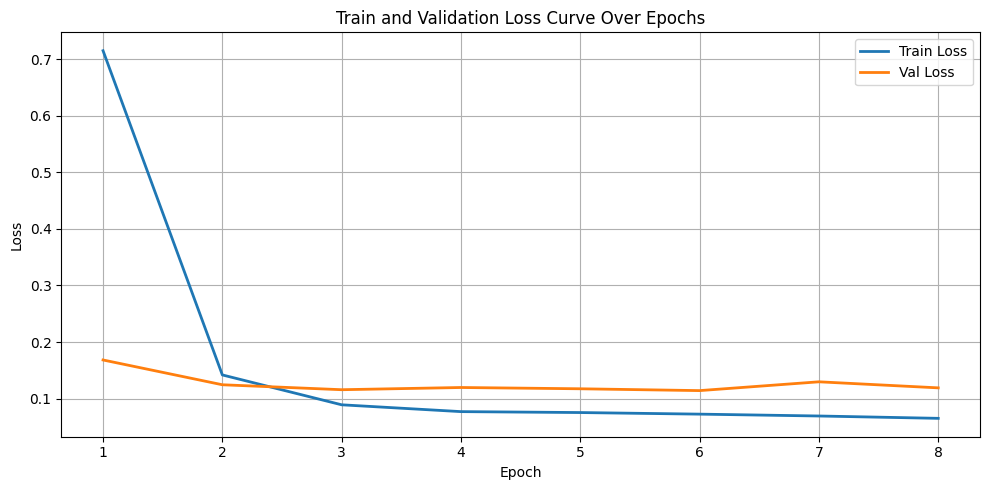

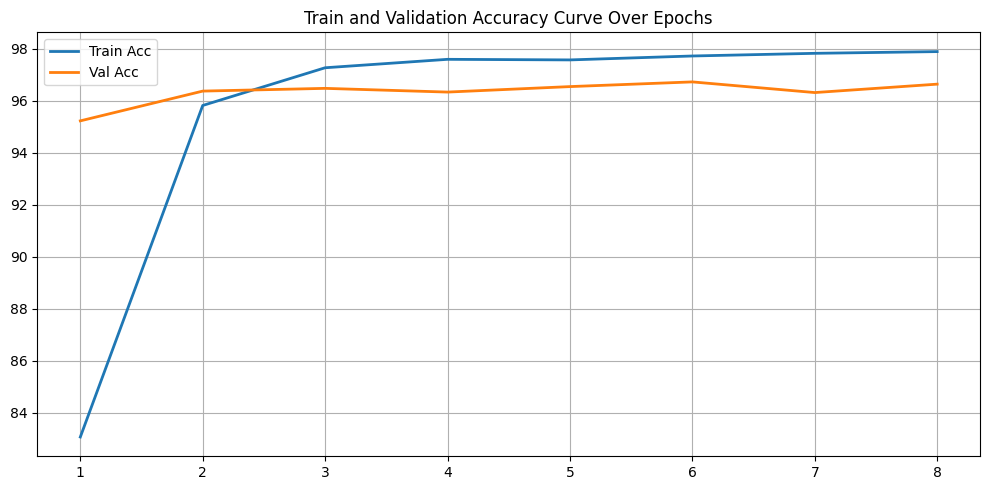

In [ ]:
vgg_epochs = range(1, len(vgg_train_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(vgg_epochs, vgg_train_loss, label='Train Loss', linewidth = 2)
plt.plot(vgg_epochs, vgg_val_loss, label='Val Loss', linewidth = 2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Train and Validation Loss Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(vgg_epochs, vgg_train_accs, label='Train Acc', linewidth = 2)
plt.plot(vgg_epochs, vgg_val_accs, label='Val Acc', linewidth = 2)
plt.legend()
plt.title("Train and Validation Accuracy Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

**Model Evaluation on Test Data**

This section evaluates the trained CNN model on unseen test data:

- **Evaluation Mode:**
  - The model is set to evaluation mode using `model.eval()` to disable dropout and batch normalization updates.

- **Metric Initialization:**
  - Variables are initialized to track correct predictions, total samples, cumulative loss, and to collect all predicted and actual labels for later analysis.

- **Inference Loop:**
  - A loop iterates over the test data loader.
  - Gradients are disabled with `torch.no_grad()` to reduce memory usage and computation.
  - Inputs and labels are transferred to the selected device (CPU, CUDA, or MPS).
  - Predictions are made by passing inputs through the model.
  - The loss is calculated and accumulated.
  - Predictions are compared to true labels to count correct predictions.
  - Predicted and actual labels are stored for metrics computation.

- **Test Accuracy and Loss:**
  - After the loop, test accuracy is calculated as the ratio of correct predictions to total samples, and average test loss is computed.

- **Classification Report:**
  - The `classification_report` function from sklearn is used to compute:
    - **Weighted Precision**
    - **Weighted Recall**
    - **Weighted F1-Score**
  - These metrics give a comprehensive summary of model performance across all classes, weighted by the number of true instances per class.

Finally, test loss, test accuracy, and weighted performance metrics are printed for model evaluation.


In [ ]:
model.load_state_dict(torch.load("best_vgg16_model.pth"))
model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nTest Loss: {test_loss / total}, Test Accuracy: {100 * correct / total}%")

vgg_test_loss = test_loss / total
vgg_test_acc = 100 * correct / total

report = classification_report(all_labels, all_preds, output_dict=True)
vgg_precision = report['weighted avg']['precision']
vgg_recall = report['weighted avg']['recall']
vgg_f1_score = report['weighted avg']['f1-score']
print(f"Weighted Precision for vgg: {vgg_precision}")
print(f"Weighted Recall for vgg:    {vgg_recall}")
print(f"Weighted F1-Score for vgg:  {vgg_f1_score}")


Test Loss: 0.12354272359530515, Test Accuracy: 96.43395657418577%
Weighted Precision for vgg: 0.9668783637940882
Weighted Recall for vgg:    0.9643395657418576
Weighted F1-Score for vgg:  0.9642122241427961


## *ResNET16*

In [ ]:
from torchvision import models, transforms, datasets
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import warnings
import time
warnings.filterwarnings("ignore")

**Dataset Preparation and DataLoader Setup**

This section prepares the dataset and splits it into training, validation, and test sets with stratified sampling:

- **Transformations:**
  - A transformation pipeline is defined using `transforms.Compose`:
    - `Resize`: Resizes all images to 224×224 pixels.
    - `ToTensor`: Converts images to PyTorch tensors.
    - `Normalize`: Normalizes pixel values to the range [-1, 1] using mean and standard deviation values of 0.5 per channel (RGB).

- **Dataset Loading:**
  - Two image datasets are loaded using `datasets.ImageFolder`, one for training and one for testing, both applying the same transform.
  - These two datasets are combined into a single dataset using `ConcatDataset`.

- **Stratified Splitting:**
  - All image-label pairs (`samples`) are extracted from both datasets.
  - Class labels (`targets`) are collected from these samples.
  - A stratified split ensures class distribution is preserved across subsets:
    - 70% of the data is used for training.
    - The remaining 30% is further split evenly into validation and test sets.
  - `train_test_split` from scikit-learn is used, first to create the training set, and then to split the remaining into validation and test.

- **Subset Creation:**
  - `Subset` objects are created from the full dataset using the calculated indices.

- **DataLoader Setup:**
  - `DataLoader` objects are created for each subset:
    - `train_loader` uses `shuffle=True` for randomness in training.
    - `val_loader` and `test_loader` use `shuffle=False` to preserve order.
    - `batch_size=512` and `num_workers=12` are set for efficient loading.
    - `pin_memory=True` speeds up data transfer to CUDA if available.

Finally, the end, it prints the number of classes and the size of each dataset split to confirm successful setup.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset_train = datasets.ImageFolder('Dataset/Training', transform=transform)
dataset_test = datasets.ImageFolder("Dataset/Test", transform=transform)

dataset = torch.utils.data.ConcatDataset([dataset_train, dataset_test])

all_samples = []
for ds in dataset.datasets:
    all_samples += ds.samples

targets = [sample[1] for sample in all_samples]
train_idx, temp_idx = train_test_split(range(len(dataset)), test_size=0.3, stratify=targets, random_state=42)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=42)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True, pin_memory=True,num_workers=12)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False, pin_memory=True,num_workers=12)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False, pin_memory=True,num_workers=12)

print("Number of classes:", len(dataset_train.classes))
print("Number of training samples:", len(train_loader.dataset))
print("Number of test samples:", len(test_loader.dataset))
print("Number of validation samples:", len(val_loader.dataset))

Number of classes: 226
Number of training samples: 123796
Number of test samples: 26528
Number of validation samples: 26528


**Transfer Learning with ResNet50**

This section configures a transfer learning model using a pre-trained ResNet50 architecture from `torchvision.models`:

- **Base Model:**
  - The `resnet50` model is loaded with `pretrained=True`, which imports weights learned from the ImageNet dataset.
  - All model parameters are frozen (`requires_grad = False`) to retain the pre-trained convolutional feature extractor without updating it during training.

- **Classifier Modification:**
  - The original fully connected classification head (`model.fc`) is replaced with a custom `nn.Sequential` block:
    - `Linear(in_features → 1024)`: Maps the output of the backbone to 1024 neurons.
    - `ReLU()`: Adds non-linearity.
    - `Dropout(0.4)`: Applies dropout regularization with a 40% drop rate to reduce overfitting.
    - `Linear(1024 → 226)`: Final classification layer maps to 226 output classes.



In [ ]:
model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False


model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(1024, 226)
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


**Device Assignment and Optimization Configuration**

- **Model Deployment:**
  - The model is moved to the selected device using `model.to(device)` so it can perform computations on the designated hardware.

- **Loss Function:**
  - `CrossEntropyLoss` is used as the loss function, which is standard for multi-class classification problems.

- **Optimizer:**
  - The Adam optimizer is used to update the model's parameters during training.
  - A learning rate of `0.0005` is set to control the step size during optimization.
  - `weight_decay=1e-4` introduces L2 regularization to help prevent overfitting by penalizing large weights.


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

**Training Loop for ResNet50 Transfer Learning Model**

This section trains the modified ResNet50 model for 20 epochs with early stopping and tracks performance metrics throughout:

- **Metric Tracking:**
  - Four lists are used to store training and validation loss and accuracy for each epoch.
  - A variable `best_val_loss` keeps track of the lowest validation loss to identify the best-performing model.
  - `stop_training_counter` is used to implement early stopping when the validation loss does not improve.

- **Training Phase (Per Epoch):**
  - The model is set to training mode.
  - Each batch of images and labels is:
    - Moved to the appropriate device (MPS, CUDA, or CPU).
    - Forwarded through the model to generate predictions.
    - Compared to the true labels using the loss function (`CrossEntropyLoss`).
    - Backpropagated through the model to compute gradients.
    - Updated using the Adam optimizer.
  - The cumulative loss and number of correct predictions are tracked to calculate training accuracy and average loss for the epoch.

- **Validation Phase (Per Epoch):**
  - The model is switched to evaluation mode with gradient tracking disabled.
  - A forward pass is performed on the validation set.
  - Validation loss and accuracy are calculated across all batches.

- **Model Checkpointing and Early Stopping:**
  - If the validation loss improves, the model’s weights are saved to `"best_resnet50_model.pth"`.
  - If the validation loss does not improve for more than 3 consecutive epochs, training is stopped early to prevent overfitting.

- **Progress Output:**
  - After each epoch, training and validation loss/accuracy are printed.

- **Training Time Measurement:**
  - Total training time for the VGG16 model is measured and printed using `time.time()` before and after training.


In [ ]:
resnet_train_loss = []
resnet_val_loss = []
resnet_train_accs = []
resnet_val_accs = []
best_val_loss = float('inf')
stop_training_counter = 0

startTime = time.time()

for epoch in range(20):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    resnet_train_loss.append(epoch_loss)
    resnet_train_accs.append(epoch_acc)

    model.eval()
    val_loss_running =0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_running += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_epoch_loss = val_loss_running / total
    val_epoch_acc = 100 * correct / total
    resnet_val_loss.append(val_epoch_loss)
    resnet_val_accs.append(val_epoch_acc)

    print(f"Epoch {epoch + 1}".format(epoch + 1, 50))
    print(f"Epoch [{epoch + 1}], Train Accuracy: {epoch_acc}%")
    print(f"Epoch [{epoch + 1}], Train Loss: {epoch_loss}")
    print(f"Epoch [{epoch + 1}], Validation Loss: {val_epoch_loss}")
    print(f"Epoch [{epoch + 1}], Validation Accuracy: {val_epoch_acc}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "best_resnet50_model.pth")
        print("best_resnet50_model.pth")
    else:
        stop_training_counter += 1
        if stop_training_counter > 3:
            print("Early stopping...")
            break
    print("↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓")
endTime = time.time()
resnet_time = endTime - startTime
print(f"Total training time for resnet: {resnet_time} seconds")

Epoch 1: 100%|██████████| 242/242 [03:49<00:00,  1.06it/s]


Epoch 1
Epoch [1], Train Accuracy: 76.50651071117%
Epoch [1], Train Loss: 1.081387779183748
Epoch [1], Validation Loss: 0.3519199669576813
Epoch [1], Validation Accuracy: 91.91420386007238
best_resnet50_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 2: 100%|██████████| 242/242 [03:48<00:00,  1.06it/s]


Epoch 2
Epoch [2], Train Accuracy: 91.59665901967753%
Epoch [2], Train Loss: 0.3265878794225931
Epoch [2], Validation Loss: 0.20538587544666126
Epoch [2], Validation Accuracy: 95.15983112183353
best_resnet50_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 3: 100%|██████████| 242/242 [03:48<00:00,  1.06it/s]


...

Epoch 18
Epoch [18], Train Accuracy: 98.48541148340819%
Epoch [18], Train Loss: 0.054437443570793685
Epoch [18], Validation Loss: 0.060528868227406205
Epoch [18], Validation Accuracy: 98.21320868516284
best_resnet50_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 19: 100%|██████████| 242/242 [03:49<00:00,  1.05it/s]


Epoch 19
Epoch [19], Train Accuracy: 98.5718440014217%
Epoch [19], Train Loss: 0.05141513647437635
Epoch [19], Validation Loss: 0.05767692570699282
Epoch [19], Validation Accuracy: 98.42807599517491
best_resnet50_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 20: 100%|██████████| 242/242 [03:49<00:00,  1.06it/s]


Epoch 20
Epoch [20], Train Accuracy: 98.60011632039807%
Epoch [20], Train Loss: 0.04998966081815951
Epoch [20], Validation Loss: 0.05754583184264681
Epoch [20], Validation Accuracy: 98.33383594692401
best_resnet50_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
Total training time for resnet: 5517.875527381897 seconds


**Visualizing Training and Validation Metrics**

This section plots the training progress over time using Matplotlib:

- **Epoch Range:**
  - The `epochs` variable is defined based on the number of recorded training loss values to align the x-axis in plots.

- **Loss Plot:**
  - A line plot is created to visualize the loss values for both training and validation over the epochs.
  - The plot includes:
    - A title: "Training Loss Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Loss"
    - A legend to distinguish between training and validation losses
    - A grid for readability
    - `tight_layout()` ensures proper spacing of plot elements

- **Accuracy Plot:**
  - A similar line plot is created to compare training and validation accuracy across epochs.
  - It includes:
    - A title: "Validation Accuracy Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Accuracy"
    - A legend to differentiate accuracy metrics
    - A grid and layout adjustment for clarity

These visualizations help monitor model performance, detect overfitting, and evaluate the effectiveness of training over time.


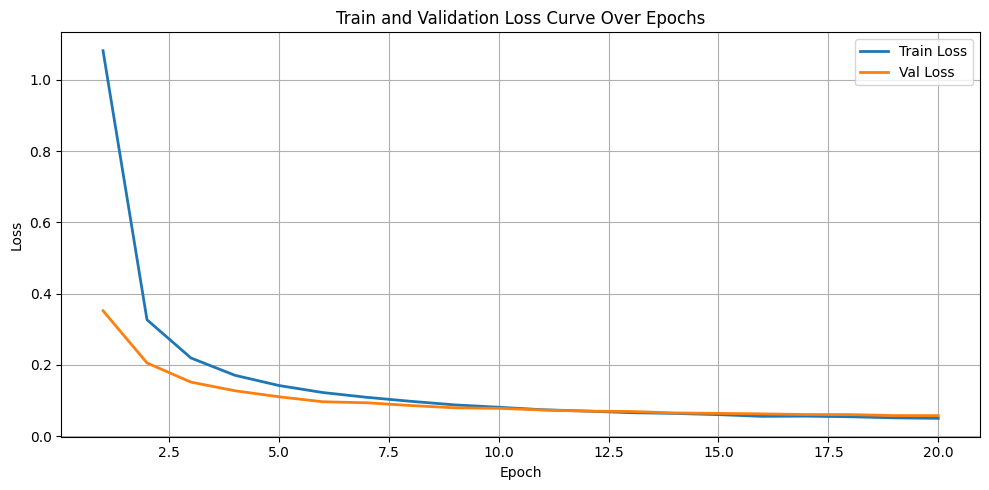

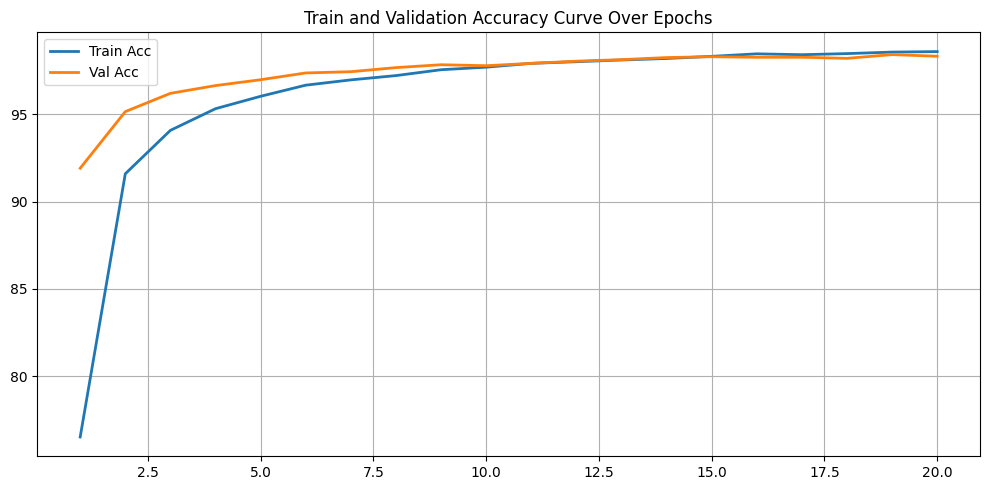

In [ ]:
resnet_epochs = range(1, len(resnet_train_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(resnet_epochs, resnet_train_loss, label='Train Loss', linewidth = 2)
plt.plot(resnet_epochs, resnet_val_loss, label='Val Loss', linewidth = 2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Train and Validation Loss Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(resnet_epochs, resnet_train_accs, label='Train Acc', linewidth = 2)
plt.plot(resnet_epochs, resnet_val_accs, label='Val Acc', linewidth = 2)
plt.legend()
plt.title("Train and Validation Accuracy Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

### 🧪 Model Evaluation on Test Data

This section evaluates the trained CNN model on unseen test data:

- **Evaluation Mode:**
  - The model is set to evaluation mode using `model.eval()` to disable dropout and batch normalization updates.

- **Metric Initialization:**
  - Variables are initialized to track correct predictions, total samples, cumulative loss, and to collect all predicted and actual labels for later analysis.

- **Inference Loop:**
  - A loop iterates over the test data loader.
  - Gradients are disabled with `torch.no_grad()` to reduce memory usage and computation.
  - Inputs and labels are transferred to the selected device (CPU, CUDA, or MPS).
  - Predictions are made by passing inputs through the model.
  - The loss is calculated and accumulated.
  - Predictions are compared to true labels to count correct predictions.
  - Predicted and actual labels are stored for metrics computation.

- **Test Accuracy and Loss:**
  - After the loop, test accuracy is calculated as the ratio of correct predictions to total samples, and average test loss is computed.

- **Classification Report:**
  - The `classification_report` function from sklearn is used to compute:
    - **Weighted Precision**
    - **Weighted Recall**
    - **Weighted F1-Score**
  - These metrics give a comprehensive summary of model performance across all classes, weighted by the number of true instances per class.

Finally, test loss, test accuracy, and weighted performance metrics are printed for model evaluation.


In [ ]:
model.load_state_dict(torch.load("best_resnet50_model.pth"))
model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nTest Loss: {test_loss / total}, Test Accuracy: {100 * correct / total}%")

resnet_test_loss = test_loss / total
resnet_test_acc = 100 * correct / total

report = classification_report(all_labels, all_preds, output_dict=True)
resnet_precision = report['weighted avg']['precision']
resnet_recall = report['weighted avg']['recall']
resnet_f1_score = report['weighted avg']['f1-score']
print(f"Weighted Precision for resnet: {resnet_precision}")
print(f"Weighted Recall for resnet:    {resnet_recall}")
print(f"Weighted F1-Score for resnet:  {resnet_f1_score}")


Test Loss: 0.06209877979536108, Test Accuracy: 98.09258142340168%
Weighted Precision for resnet: 0.9817555445009201
Weighted Recall for resnet:    0.9809258142340169
Weighted F1-Score for resnet:  0.9807507954465666


## *MobileNet*

In [ ]:
from torchvision import models, transforms, datasets
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import warnings
import time
warnings.filterwarnings("ignore")

**Dataset Preparation and DataLoader Setup**

This section prepares the dataset and splits it into training, validation, and test sets with stratified sampling:

- **Transformations:**
  - A transformation pipeline is defined using `transforms.Compose`:
    - `Resize`: Resizes all images to 224×224 pixels.
    - `ToTensor`: Converts images to PyTorch tensors.
    - `Normalize`: Normalizes pixel values to the range [-1, 1] using mean and standard deviation values of 0.5 per channel (RGB).

- **Dataset Loading:**
  - Two image datasets are loaded using `datasets.ImageFolder`, one for training and one for testing, both applying the same transform.
  - These two datasets are combined into a single dataset using `ConcatDataset`.

- **Stratified Splitting:**
  - All image-label pairs (`samples`) are extracted from both datasets.
  - Class labels (`targets`) are collected from these samples.
  - A stratified split ensures class distribution is preserved across subsets:
    - 70% of the data is used for training.
    - The remaining 30% is further split evenly into validation and test sets.
  - `train_test_split` from scikit-learn is used, first to create the training set, and then to split the remaining into validation and test.

- **Subset Creation:**
  - `Subset` objects are created from the full dataset using the calculated indices.

- **DataLoader Setup:**
  - `DataLoader` objects are created for each subset:
    - `train_loader` uses `shuffle=True` for randomness in training.
    - `val_loader` and `test_loader` use `shuffle=False` to preserve order.
    - `batch_size=512` and `num_workers=12` are set for efficient loading.
    - `pin_memory=True` speeds up data transfer to CUDA if available.

Finally, the end, it prints the number of classes and the size of each dataset split to confirm successful setup.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset_train = datasets.ImageFolder('Dataset/Training', transform=transform)
dataset_test = datasets.ImageFolder("Dataset/Test", transform=transform)
dataset = torch.utils.data.ConcatDataset([dataset_train, dataset_test])

all_samples = []
for ds in dataset.datasets:
    all_samples += ds.samples

targets = [sample[1] for sample in all_samples]
train_idx, temp_idx = train_test_split(range(len(all_samples)), test_size=0.3, stratify=targets, random_state=42)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=42)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True, pin_memory=True, num_workers=12)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False, pin_memory=True, num_workers=12)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False, pin_memory=True, num_workers=12)

print("Number of classes:", len(dataset_train.classes))
print("Number of training samples:", len(train_loader.dataset))
print("Number of test samples:", len(test_loader.dataset))
print("Number of validation samples:", len(val_loader.dataset))

Number of classes: 226
Number of training samples: 123796
Number of test samples: 26528
Number of validation samples: 26528


**Transfer Learning with MobileNet**

This section configures a transfer learning model using a pre-trained MobileNet architecture from `torchvision.models`:

- **Base Model:**
  - The `MobileNet` model is loaded with `pretrained=True`, which imports weights learned from the ImageNet dataset.
  - All model parameters are frozen (`requires_grad = False`) to retain the pre-trained convolutional feature extractor without updating it during training.

- **Classifier Modification:**
  - The original fully connected classification head (`model.fc`) is replaced with a custom `nn.Sequential` block:
    - `Linear(in_features → 1024)`: Maps the output of the backbone to 1024 neurons.
    - `ReLU()`: Adds non-linearity.
    - `Dropout(0.4)`: Applies dropout regularization with a 40% drop rate to reduce overfitting.
    - `Linear(1024 → 226)`: Final classification layer maps to 226 output classes.



In [ ]:
model = models.mobilenet_v3_large(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(model.classifier[0].in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(1024, 226)
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 193MB/s]


**Model Device Setup and Optimization Configuration**

- **Model Deployment:**
  - The model is moved to the selected device with `model.to(device)` to ensure compatibility during training and inference.

- **Loss Function:**
  - `CrossEntropyLoss` is used as the criterion, which is suitable for multi-class classification tasks.

- **Optimizer:**
  - The Adam optimizer is selected for its adaptive learning rate capabilities.
  - A learning rate of `0.0005` is used.
  - `weight_decay=1e-4` applies L2 regularization to prevent overfitting by penalizing large weights.


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

**Training Loop for MobileNet Transfer Learning Model**

This section trains the modified MobileNet model for 20 epochs with early stopping and tracks performance metrics throughout:

- **Metric Tracking:**
  - Four lists are used to store training and validation loss and accuracy for each epoch.
  - A variable `best_val_loss` keeps track of the lowest validation loss to identify the best-performing model.
  - `stop_training_counter` is used to implement early stopping when the validation loss does not improve.

- **Training Phase (Per Epoch):**
  - The model is set to training mode.
  - Each batch of images and labels is:
    - Moved to the appropriate device (MPS, CUDA, or CPU).
    - Forwarded through the model to generate predictions.
    - Compared to the true labels using the loss function (`CrossEntropyLoss`).
    - Backpropagated through the model to compute gradients.
    - Updated using the Adam optimizer.
  - The cumulative loss and number of correct predictions are tracked to calculate training accuracy and average loss for the epoch.

- **Validation Phase (Per Epoch):**
  - The model is switched to evaluation mode with gradient tracking disabled.
  - A forward pass is performed on the validation set.
  - Validation loss and accuracy are calculated across all batches.

- **Model Checkpointing and Early Stopping:**
  - If the validation loss improves, the model’s weights are saved to `"best_mobileNetV3_model.pth"`.
  - If the validation loss does not improve for more than 3 consecutive epochs, training is stopped early to prevent overfitting.

- **Progress Output:**
  - After each epoch, training and validation loss/accuracy are printed.

- **Training Time Measurement:**
  - Total training time for the VGG16 model is measured and printed using `time.time()` before and after training.


In [ ]:
mobilenet_train_loss = []
mobilenet_val_loss = []
mobilenet_train_accs = []
mobilenet_val_accs = []
best_val_loss = float('inf')
stop_training_counter = 0

startTime = time.time()

for epoch in range(20):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    mobilenet_train_loss.append(epoch_loss)
    mobilenet_train_accs.append(epoch_acc)

    model.eval()
    val_loss_running = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_running += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_epoch_loss = val_loss_running / total
    val_epoch_acc = 100 * correct / total
    mobilenet_val_loss.append(val_epoch_loss)
    mobilenet_val_accs.append(val_epoch_acc)

    print(f"Epoch [{epoch + 1}/20]")
    print(f"Train Accuracy: {epoch_acc}%")
    print(f"Train Loss: {epoch_loss}")
    print(f"Validation Loss: {val_epoch_loss}")
    print(f"Validation Accuracy: {val_epoch_acc}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "best_mobilenetv3_model.pth")
        print("Saved best_mobilenetv3_model.pth")
    else:
        stop_training_counter += 1
        if stop_training_counter > 10:
            print("Early stopping...")
            break
    print("↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓")

endTime = time.time()
mobilenet_time = endTime - startTime
print(f"Total training time for mobilenet: {mobilenet_time} seconds")

Epoch 1: 100%|██████████| 242/242 [01:22<00:00,  2.95it/s]


Epoch [1/20]
Train Accuracy: 73.83518045817313%
Train Loss: 1.240241874707389
Validation Loss: 0.38185409998433584
Validation Accuracy: 91.46185162846804
Saved best_mobilenetv3_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 2: 100%|██████████| 242/242 [01:22<00:00,  2.95it/s]


Epoch [2/20]
Train Accuracy: 92.11363856667421%
Train Loss: 0.31884650353114435
Validation Loss: 0.20953465108417055
Validation Accuracy: 94.86580217129071
Saved best_mobilenetv3_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 3: 100%|██████████| 242/242 [01:22<00:00,  2.94it/s]


...

Epoch [18/20]
Train Accuracy: 99.05328120456234%
Train Loss: 0.042811826226194095
Validation Loss: 0.058845372720024984
Validation Accuracy: 98.42430639324488
Saved best_mobilenetv3_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 19: 100%|██████████| 242/242 [01:22<00:00,  2.93it/s]


Epoch [19/20]
Train Accuracy: 99.16879382209441%
Train Loss: 0.03983643173301423
Validation Loss: 0.061307701117059146
Validation Accuracy: 98.29613992762364
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 20: 100%|██████████| 242/242 [01:21<00:00,  2.96it/s]


Epoch [20/20]
Train Accuracy: 99.12355811173221%
Train Loss: 0.039347159336483105
Validation Loss: 0.062219969820415444
Validation Accuracy: 98.19059107358262
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
Total training time for mobilenet: 2023.0578618049622 seconds


**Visualizing Training and Validation Metrics**

This section plots the training progress over time using Matplotlib:

- **Epoch Range:**
  - The `epochs` variable is defined based on the number of recorded training loss values to align the x-axis in plots.

- **Loss Plot:**
  - A line plot is created to visualize the loss values for both training and validation over the epochs.
  - The plot includes:
    - A title: "Training Loss Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Loss"
    - A legend to distinguish between training and validation losses
    - A grid for readability
    - `tight_layout()` ensures proper spacing of plot elements

- **Accuracy Plot:**
  - A similar line plot is created to compare training and validation accuracy across epochs.
  - It includes:
    - A title: "Validation Accuracy Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Accuracy"
    - A legend to differentiate accuracy metrics
    - A grid and layout adjustment for clarity

These visualizations help monitor model performance, detect overfitting, and evaluate the effectiveness of training over time.


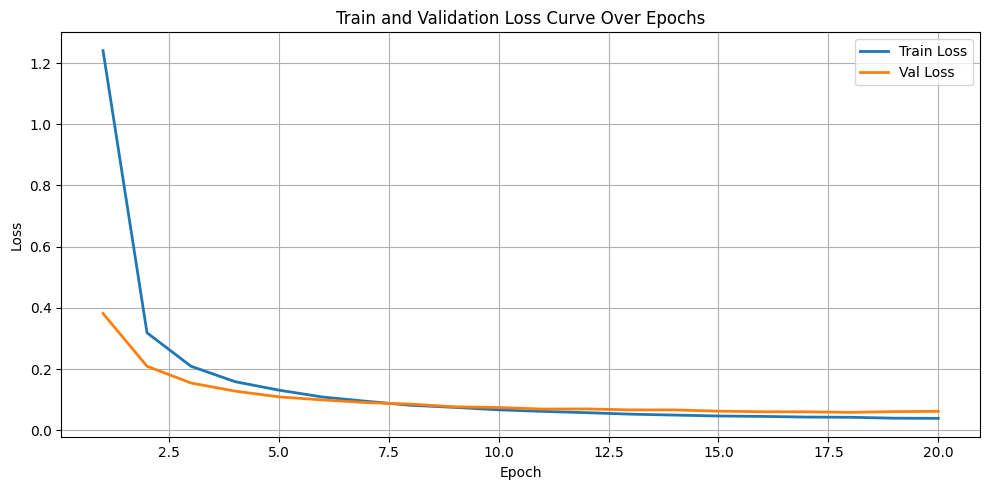

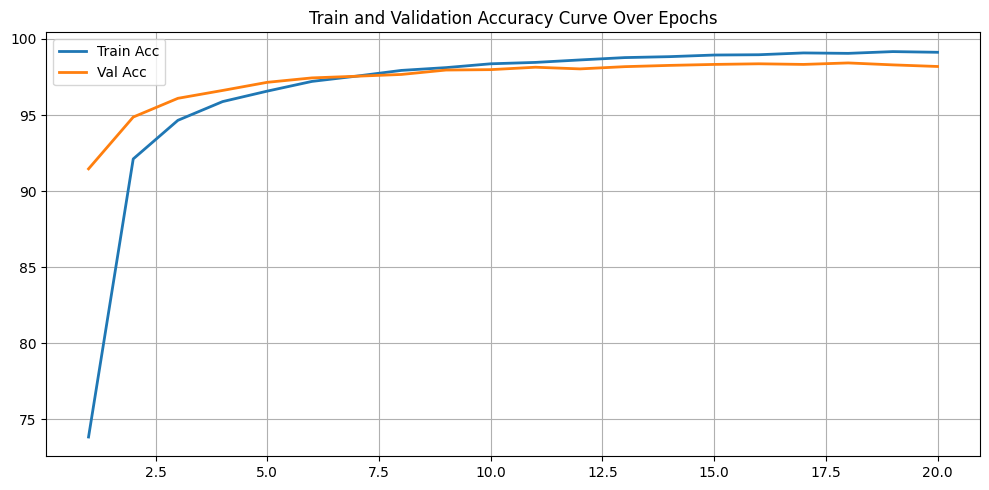

In [ ]:
mobilenet_epochs = range(1, len(mobilenet_train_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(mobilenet_epochs, mobilenet_train_loss, label='Train Loss', linewidth=2)
plt.plot(mobilenet_epochs, mobilenet_val_loss, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Train and Validation Loss Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(mobilenet_epochs, mobilenet_train_accs, label='Train Acc', linewidth=2)
plt.plot(mobilenet_epochs, mobilenet_val_accs, label='Val Acc', linewidth=2)
plt.legend()
plt.title("Train and Validation Accuracy Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

**Model Evaluation on Test Data**

This section evaluates the trained CNN model on unseen test data:

- **Evaluation Mode:**
  - The model is set to evaluation mode using `model.eval()` to disable dropout and batch normalization updates.

- **Metric Initialization:**
  - Variables are initialized to track correct predictions, total samples, cumulative loss, and to collect all predicted and actual labels for later analysis.

- **Inference Loop:**
  - A loop iterates over the test data loader.
  - Gradients are disabled with `torch.no_grad()` to reduce memory usage and computation.
  - Inputs and labels are transferred to the selected device (CPU, CUDA, or MPS).
  - Predictions are made by passing inputs through the model.
  - The loss is calculated and accumulated.
  - Predictions are compared to true labels to count correct predictions.
  - Predicted and actual labels are stored for metrics computation.

- **Test Accuracy and Loss:**
  - After the loop, test accuracy is calculated as the ratio of correct predictions to total samples, and average test loss is computed.

- **Classification Report:**
  - The `classification_report` function from sklearn is used to compute:
    - **Weighted Precision**
    - **Weighted Recall**
    - **Weighted F1-Score**
  - These metrics give a comprehensive summary of model performance across all classes, weighted by the number of true instances per class.

Finally, test loss, test accuracy, and weighted performance metrics are printed for model evaluation.


In [ ]:
model.load_state_dict(torch.load("best_mobilenetv3_model.pth"))
model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nTest Loss: {test_loss / total:.4f}, Test Accuracy: {100 * correct / total:.2f}%")

mobilenet_test_loss = test_loss / total
mobilenet_test_acc = 100 * correct / total

report = classification_report(all_labels, all_preds, output_dict=True)
mobilenet_precision = report['weighted avg']['precision']
mobilenet_recall = report['weighted avg']['recall']
mobilenet_f1_score = report['weighted avg']['f1-score']
print(f"Weighted Precision for mobilenet: {mobilenet_precision}")
print(f"Weighted Recall for mobilenet:    {mobilenet_recall}")
print(f"Weighted F1-Score for mobilenet:  {mobilenet_f1_score}")


Test Loss: 0.0618, Test Accuracy: 98.30%
Weighted Precision for mobilenet: 0.9835696420158463
Weighted Recall for mobilenet:    0.9830367913148371
Weighted F1-Score for mobilenet:  0.9828738447846442


## *EfficientNet*

In [ ]:
from torchvision import models, transforms, datasets
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import warnings
import time
warnings.filterwarnings("ignore")

**Dataset Preparation and DataLoader Setup**

This section prepares the dataset and splits it into training, validation, and test sets with stratified sampling:

- **Transformations:**
  - A transformation pipeline is defined using `transforms.Compose`:
    - `Resize`: Resizes all images to 224×224 pixels.
    - `ToTensor`: Converts images to PyTorch tensors.
    - `Normalize`: Normalizes pixel values to the range [-1, 1] using mean and standard deviation values of 0.5 per channel (RGB).

- **Dataset Loading:**
  - Two image datasets are loaded using `datasets.ImageFolder`, one for training and one for testing, both applying the same transform.
  - These two datasets are combined into a single dataset using `ConcatDataset`.

- **Stratified Splitting:**
  - All image-label pairs (`samples`) are extracted from both datasets.
  - Class labels (`targets`) are collected from these samples.
  - A stratified split ensures class distribution is preserved across subsets:
    - 70% of the data is used for training.
    - The remaining 30% is further split evenly into validation and test sets.
  - `train_test_split` from scikit-learn is used, first to create the training set, and then to split the remaining into validation and test.

- **Subset Creation:**
  - `Subset` objects are created from the full dataset using the calculated indices.

- **DataLoader Setup:**
  - `DataLoader` objects are created for each subset:
    - `train_loader` uses `shuffle=True` for randomness in training.
    - `val_loader` and `test_loader` use `shuffle=False` to preserve order.
    - `batch_size=512` and `num_workers=12` are set for efficient loading.
    - `pin_memory=True` speeds up data transfer to CUDA if available.

Finally, the end, it prints the number of classes and the size of each dataset split to confirm successful setup.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset_train = datasets.ImageFolder('Dataset/Training', transform=transform)
dataset_test = datasets.ImageFolder("Dataset/Test", transform=transform)
dataset = torch.utils.data.ConcatDataset([dataset_train, dataset_test])

all_samples = []
for ds in dataset.datasets:
    all_samples += ds.samples

targets = [sample[1] for sample in all_samples]
train_idx, temp_idx = train_test_split(range(len(all_samples)), test_size=0.3, stratify=targets, random_state=42)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=42)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True, pin_memory=True, num_workers=16)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False, pin_memory=True, num_workers=16)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False, pin_memory=True, num_workers=16)

print("Number of classes:", len(dataset_train.classes))
print("Number of training samples:", len(train_loader.dataset))
print("Number of test samples:", len(test_loader.dataset))
print("Number of validation samples:", len(val_loader.dataset))

Number of classes: 226
Number of training samples: 123796
Number of test samples: 26528
Number of validation samples: 26528


**Transfer Learning with EfficientNet**

This section configures a transfer learning model using a pre-trained EfficientNet architecture from `torchvision.models`:

- **Base Model:**
  - The `EfficientNet` model is loaded with `pretrained=True`, which imports weights learned from the ImageNet dataset.
  - All model parameters are frozen (`requires_grad = False`) to retain the pre-trained convolutional feature extractor without updating it during training.

- **Classifier Modification:**
  - The original fully connected classification head (`model.fc`) is replaced with a custom `nn.Sequential` block:
    - `Linear(in_features → 1024)`: Maps the output of the backbone to 1024 neurons.
    - `ReLU()`: Adds non-linearity.
    - `Dropout(0.4)`: Applies dropout regularization with a 40% drop rate to reduce overfitting.
    - `Linear(1024 → 226)`: Final classification layer maps to 226 output classes.



In [ ]:
model = models.efficientnet_b0(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(1024, 226)
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 215MB/s]


**Model Device Setup and Optimization Configuration**

- **Model Deployment:**
  - The model is moved to the selected device with `model.to(device)` to ensure compatibility during training and inference.

- **Loss Function:**
  - `CrossEntropyLoss` is used as the criterion, which is suitable for multi-class classification tasks.

- **Optimizer:**
  - The Adam optimizer is selected for its adaptive learning rate capabilities.
  - A learning rate of `0.0005` is used.
  - `weight_decay=1e-4` applies L2 regularization to prevent overfitting by penalizing large weights.


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

**Training Loop for EfficientNet Transfer Learning Model**

This section trains the modified MobileNet model for 20 epochs with early stopping and tracks performance metrics throughout:

- **Metric Tracking:**
  - Four lists are used to store training and validation loss and accuracy for each epoch.
  - A variable `best_val_loss` keeps track of the lowest validation loss to identify the best-performing model.
  - `stop_training_counter` is used to implement early stopping when the validation loss does not improve.

- **Training Phase (Per Epoch):**
  - The model is set to training mode.
  - Each batch of images and labels is:
    - Moved to the appropriate device (MPS, CUDA, or CPU).
    - Forwarded through the model to generate predictions.
    - Compared to the true labels using the loss function (`CrossEntropyLoss`).
    - Backpropagated through the model to compute gradients.
    - Updated using the Adam optimizer.
  - The cumulative loss and number of correct predictions are tracked to calculate training accuracy and average loss for the epoch.

- **Validation Phase (Per Epoch):**
  - The model is switched to evaluation mode with gradient tracking disabled.
  - A forward pass is performed on the validation set.
  - Validation loss and accuracy are calculated across all batches.

- **Model Checkpointing and Early Stopping:**
  - If the validation loss improves, the model’s weights are saved to `"best_efficientnetb0_model.pth"`.
  - If the validation loss does not improve for more than 3 consecutive epochs, training is stopped early to prevent overfitting.

- **Progress Output:**
  - After each epoch, training and validation loss/accuracy are printed.

- **Training Time Measurement:**
  - Total training time for the VGG16 model is measured and printed using `time.time()` before and after training.


In [ ]:
efficientnet_train_loss = []
efficientnet_val_loss = []
efficientnet_train_accs = []
efficientnet_val_accs = []
best_val_loss = float('inf')
stop_training_counter = 0

startTime = time.time()

for epoch in range(20):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    efficientnet_train_loss.append(epoch_loss)
    efficientnet_train_accs.append(epoch_acc)

    model.eval()
    val_loss_running = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_running += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_epoch_loss = val_loss_running / total
    val_epoch_acc = 100 * correct / total
    efficientnet_val_loss.append(val_epoch_loss)
    efficientnet_val_accs.append(val_epoch_acc)

    print(f"Epoch [{epoch + 1}/20]")
    print(f"Train Accuracy: {epoch_acc}%")
    print(f"Train Loss: {epoch_loss}")
    print(f"Validation Loss: {val_epoch_loss}")
    print(f"Validation Accuracy: {val_epoch_acc}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "best_efficientnet_model.pth")
        print("Saved best_efficientnet_model.pth")
    else:
        stop_training_counter += 1
        if stop_training_counter > 10:
            print("Early stopping...")
            break
    print("↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓")

endTime = time.time()
efficientnet_time = endTime - startTime
print(f"Total training time for efficientnet: {efficientnet_time} seconds")

Epoch 1: 100%|██████████| 242/242 [02:11<00:00,  1.83it/s]


Epoch [1/20]
Train Accuracy: 74.90952857927559%
Train Loss: 1.2773823310490813
Validation Loss: 0.3557500883811058
Validation Accuracy: 91.97451749095296
Saved best_efficientnet_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 2: 100%|██████████| 242/242 [02:10<00:00,  1.86it/s]


Epoch [2/20]
Train Accuracy: 91.71944166208924%
Train Loss: 0.3455020264992364
Validation Loss: 0.19827938358444355
Validation Accuracy: 95.44632086851628
Saved best_efficientnet_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 3: 100%|██████████| 242/242 [02:10<00:00,  1.85it/s]


...

Epoch [18/20]
Train Accuracy: 98.50156709425184%
Train Loss: 0.06426007534660173
Validation Loss: 0.06424338077571337
Validation Accuracy: 98.40168878166466
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 19: 100%|██████████| 242/242 [02:10<00:00,  1.85it/s]


Epoch [19/20]
Train Accuracy: 98.60577078419335%
Train Loss: 0.06061651298879244
Validation Loss: 0.06472602078581029
Validation Accuracy: 98.26598311218335
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓


Epoch 20: 100%|██████████| 242/242 [02:09<00:00,  1.87it/s]


Epoch [20/20]
Train Accuracy: 98.59769297877153%
Train Loss: 0.06020470542210963
Validation Loss: 0.06286865413476532
Validation Accuracy: 98.32629674306393
Saved best_efficientnet_model.pth
↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
Total training time for efficientnet: 3182.884072780609 seconds


**Visualizing Training and Validation Metrics**

This section plots the training progress over time using Matplotlib:

- **Epoch Range:**
  - The `epochs` variable is defined based on the number of recorded training loss values to align the x-axis in plots.

- **Loss Plot:**
  - A line plot is created to visualize the loss values for both training and validation over the epochs.
  - The plot includes:
    - A title: "Training Loss Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Loss"
    - A legend to distinguish between training and validation losses
    - A grid for readability
    - `tight_layout()` ensures proper spacing of plot elements

- **Accuracy Plot:**
  - A similar line plot is created to compare training and validation accuracy across epochs.
  - It includes:
    - A title: "Validation Accuracy Over Epochs"
    - X-axis labeled as "Epoch"
    - Y-axis labeled as "Accuracy"
    - A legend to differentiate accuracy metrics
    - A grid and layout adjustment for clarity

These visualizations help monitor model performance, detect overfitting, and evaluate the effectiveness of training over time.


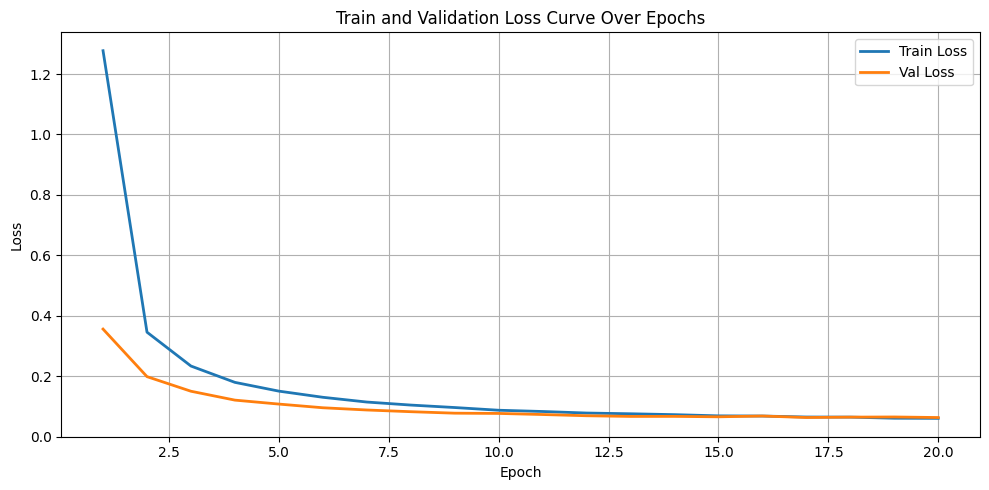

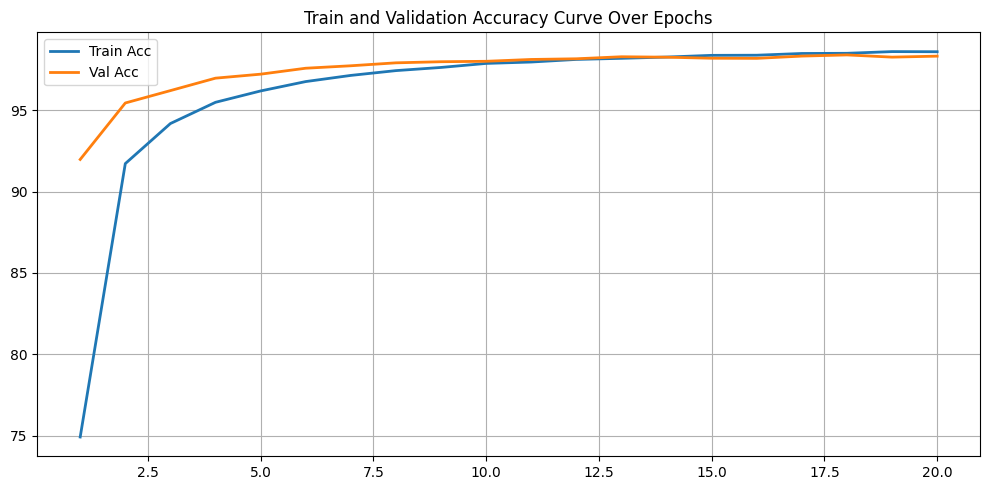

In [ ]:
efficientnet_epochs = range(1, len(efficientnet_train_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(efficientnet_epochs, efficientnet_train_loss, label='Train Loss', linewidth=2)
plt.plot(efficientnet_epochs, efficientnet_val_loss, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Train and Validation Loss Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(efficientnet_epochs, efficientnet_train_accs, label='Train Acc', linewidth=2)
plt.plot(efficientnet_epochs, efficientnet_val_accs, label='Val Acc', linewidth=2)
plt.legend()
plt.title("Train and Validation Accuracy Curve Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

**Model Evaluation on Test Data**

This section evaluates the trained CNN model on unseen test data:

- **Evaluation Mode:**
  - The model is set to evaluation mode using `model.eval()` to disable dropout and batch normalization updates.

- **Metric Initialization:**
  - Variables are initialized to track correct predictions, total samples, cumulative loss, and to collect all predicted and actual labels for later analysis.

- **Inference Loop:**
  - A loop iterates over the test data loader.
  - Gradients are disabled with `torch.no_grad()` to reduce memory usage and computation.
  - Inputs and labels are transferred to the selected device (CPU, CUDA, or MPS).
  - Predictions are made by passing inputs through the model.
  - The loss is calculated and accumulated.
  - Predictions are compared to true labels to count correct predictions.
  - Predicted and actual labels are stored for metrics computation.

- **Test Accuracy and Loss:**
  - After the loop, test accuracy is calculated as the ratio of correct predictions to total samples, and average test loss is computed.

- **Classification Report:**
  - The `classification_report` function from sklearn is used to compute:
    - **Weighted Precision**
    - **Weighted Recall**
    - **Weighted F1-Score**
  - These metrics give a comprehensive summary of model performance across all classes, weighted by the number of true instances per class.

Finally, test loss, test accuracy, and weighted performance metrics are printed for model evaluation.


In [ ]:
model.load_state_dict(torch.load("best_efficientnet_model.pth"))
model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nTest Loss: {test_loss / total:.4f}, Test Accuracy: {100 * correct / total:.2f}%")

efficientnet_test_loss = test_loss / total
efficientnet_test_acc = 100 * correct / total

report = classification_report(all_labels, all_preds, output_dict=True)
efficientnet_precision = report['weighted avg']['precision']
efficientnet_recall = report['weighted avg']['recall']
efficientnet_f1_score = report['weighted avg']['f1-score']
print(f"Weighted Precision for efficientnet: {efficientnet_precision}")
print(f"Weighted Recall for efficientnet:    {efficientnet_recall}")
print(f"Weighted F1-Score for efficientnet:  {efficientnet_f1_score}")


Test Loss: 0.0704, Test Accuracy: 98.19%
Weighted Precision for efficientnet: 0.982620054469773
Weighted Recall for efficientnet:    0.981868214716526
Weighted F1-Score for efficientnet:  0.9817248278633739


# **Results**

**Comparative Performance Visualization of 5 Models**

This section visualizes and compares the training, validation, and test performance of five different models:

**Models Compared:**
- Custom CNN
- VGG16
- ResNet50
- MobileNetV3
- EfficientNetB0

For each model, the following metrics are collected and visualized:
- **Best Training Accuracy**: Highest accuracy achieved on the training set during training.
- **Best Validation Accuracy**: Peak validation accuracy across all epochs.
- **Test Accuracy**: Final accuracy measured on the unseen test dataset.
- **Best Training Loss**: Lowest training loss recorded during training.
- **Best Validation Loss**: Lowest validation loss across epochs.
- **Test Loss**: Final average loss on the test dataset.

**Visualization Details:**
- The data is presented as bar charts in a 2×3 grid using `matplotlib`.
- Each subplot displays one metric across the five models:
  - Top row: Train Accuracy, Validation Accuracy, Test Accuracy
  - Bottom row: Train Loss, Validation Loss, Test Loss
- Distinct colors are used for each chart to enhance readability.
- Grid lines and subplot titles are added for clarity.
- A main title "Performance Comparison of 5 Models" provides overall context.

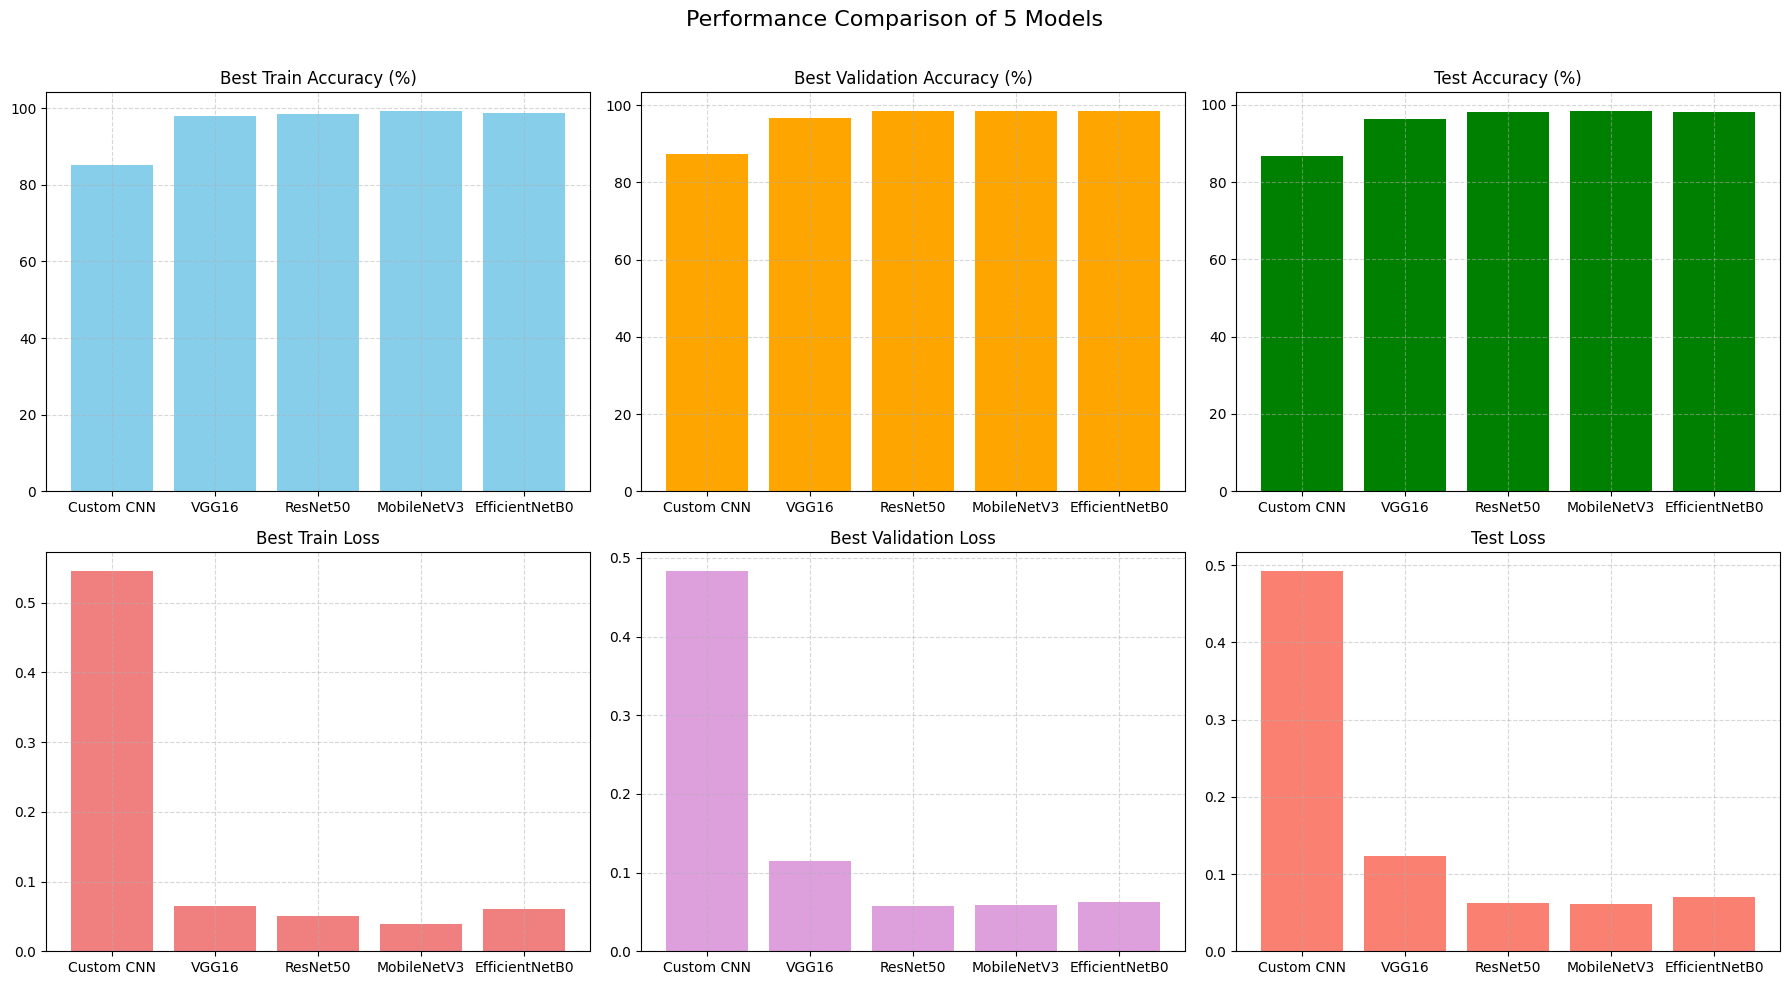

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Custom CNN', 'VGG16', 'ResNet50', 'MobileNetV3', 'EfficientNetB0']


best_val_losses = [
    min(val_losses),
    min(vgg_val_loss),
    min(resnet_val_loss),
    min(mobilenet_val_loss),
    min(efficientnet_val_loss)
]

best_val_accs = [
    max(val_accuracys),
    max(vgg_val_accs),
    max(resnet_val_accs),
    max(mobilenet_val_accs),
    max(efficientnet_val_accs)
]

best_train_losses = [
    min(train_loss),
    min(vgg_train_loss),
    min(resnet_train_loss),
    min(mobilenet_train_loss),
    min(efficientnet_train_loss)
]

best_train_accs = [
    max(train_accuracies),
    max(vgg_train_accs),
    max(resnet_train_accs),
    max(mobilenet_train_accs),
    max(efficientnet_train_accs)
]

test_accs = [
    test_accuracy,
    vgg_test_acc,
    resnet_test_acc,
    mobilenet_test_acc,
    efficientnet_test_acc,
]

test_losses = [
    avg_test_loss,
    vgg_test_loss,
    resnet_test_loss,
    mobilenet_test_loss,
    efficientnet_test_loss,
]

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

axs[0, 0].bar(models, best_train_accs, color='skyblue')
axs[0, 0].set_title('Best Train Accuracy (%)')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

axs[0, 1].bar(models, best_val_accs, color='orange')
axs[0, 1].set_title('Best Validation Accuracy (%)')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

axs[0, 2].bar(models, test_accs, color='green')
axs[0, 2].set_title('Test Accuracy (%)')
axs[0, 2].grid(True, linestyle='--', alpha=0.5)

axs[1, 0].bar(models, best_train_losses, color='lightcoral')
axs[1, 0].set_title('Best Train Loss')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

axs[1, 1].bar(models, best_val_losses, color='plum')
axs[1, 1].set_title('Best Validation Loss')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

axs[1, 2].bar(models, test_losses, color='salmon')
axs[1, 2].set_title('Test Loss')
axs[1, 2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Performance Comparison of 5 Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


**Training Time Comparison of Plant Classification Models**

This section visualizes the total training time (in minutes) for each of the five deep learning models used in the plant classification task:

**Models Compared:**
- Custom CNN
- VGG16 (Transfer Learning)
- ResNet50 (Transfer Learning)
- MobileNet (Transfer Learning)
- EfficientNet (Transfer Learning)

**What the Chart Shows:**
- A bar chart is created to compare how long each model took to train.
- The training times, originally in seconds, are converted to minutes for easier interpretation.
```python
training_times_minutes = [t / 60 for t in training_times]
```
- Each bar represents one model, and its height corresponds to its total training duration.
- The x-axis displays the model names, while the y-axis shows training time in minutes.
- `tight_layout()` is used to ensure proper spacing and readability of labels and titles.


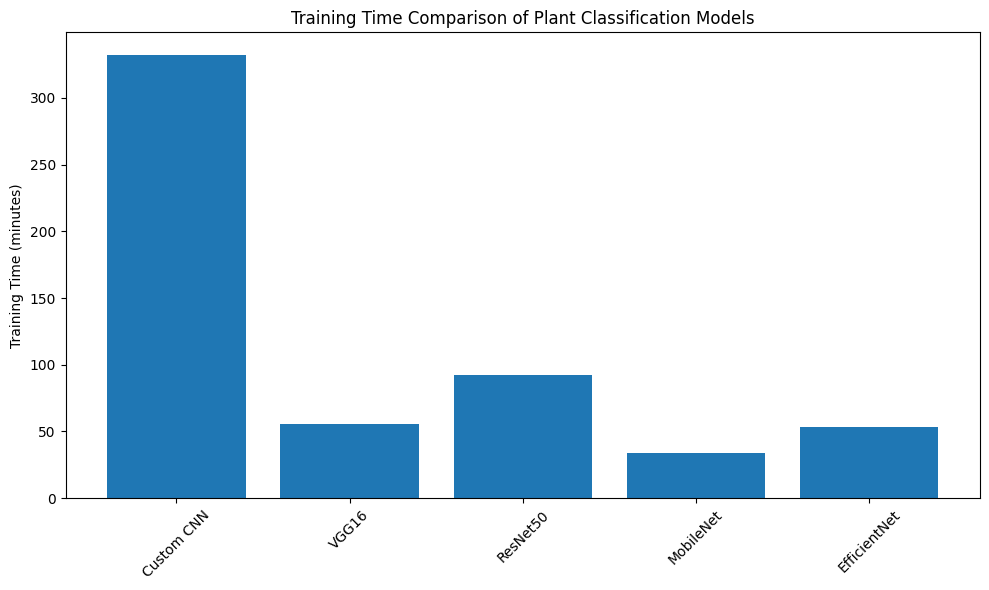

In [ ]:
import matplotlib.pyplot as plt

model_names = ['Custom CNN', 'VGG16', 'ResNet50', 'MobileNet', 'EfficientNet']
training_times = [customCNN_time, VGG_time, resnet_time, mobilenet_time, efficientnet_time]

training_times_minutes = [t / 60 for t in training_times]

plt.figure(figsize=(10, 6))
plt.bar(model_names, training_times_minutes)
plt.ylabel('Training Time (minutes)')
plt.title('Training Time Comparison of Plant Classification Models')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Precision, Recall, and F1-Score Comparison (Weighted Average)**

This section visualizes the weighted average classification performance metrics precision, recall, and F1-score for five different plant classification models, evaluated on the test set:

**Models Compared:**
- Custom CNN
- VGG16
- ResNet50
- MobileNetV3
- EfficientNetB0

**Visualization Details:**
- A grouped bar chart is used, with each group representing a model and each bar within a group representing one of the three metrics.
- The `width` variable controls spacing between the bars in each group.
- The bars are color-coded and labeled for easy comparison.
- Y-axis is capped at 1.1 to ensure all values (which range from 0 to 1) are clearly visible.
- Grid lines on the y-axis improve readability.


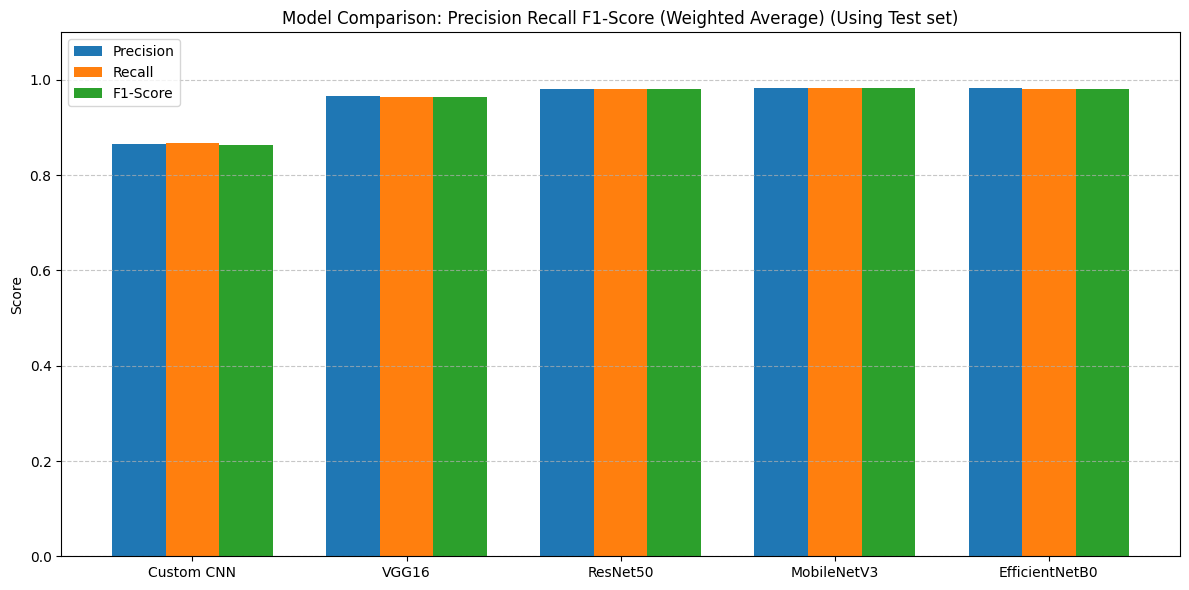

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Custom CNN', 'VGG16', 'ResNet50', 'MobileNetV3', 'EfficientNetB0']

precisions = [custom_precision ,vgg_precision, resnet_precision, mobilenet_precision, efficientnet_precision]
recalls = [custom_recall, vgg_recall, resnet_recall, mobilenet_recall, efficientnet_recall]
f1_scores = [custom_f1_score, vgg_f1_score, resnet_f1_score, mobilenet_f1_score, efficientnet_f1_score]


x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precisions, width, label='Precision')
bars2 = ax.bar(x, recalls, width, label='Recall')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Precision Recall F1-Score (Weighted Average) (Using Test set)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Model Training Summary Table**

This section presents a summary table that consolidates key training and evaluation metrics for all five plant classification models:

**Models Included:**
- Custom CNN
- VGG16
- ResNet50
- MobileNet
- EfficientNet

**Metrics Displayed:**
- **Time (min):** Total training time for each model, converted from seconds to minutes and formatted to 4 decimal places.
- **Train Accuracy:** The highest training accuracy achieved during training, shown as a percentage.
- **Test Accuracy:** Final accuracy on the unseen test dataset.
- **Train Loss:** The lowest training loss recorded during training.
- **Test Loss:** Average loss on the test dataset.

**Visualization Details:**
- A static table is created using `matplotlib`'s `table()` method.
- The table includes well-labeled columns and is centered within the plot.
- Font size is manually set for readability, and row/column cell alignment is centered.
- `tight_layout()` ensures spacing is optimized for display.

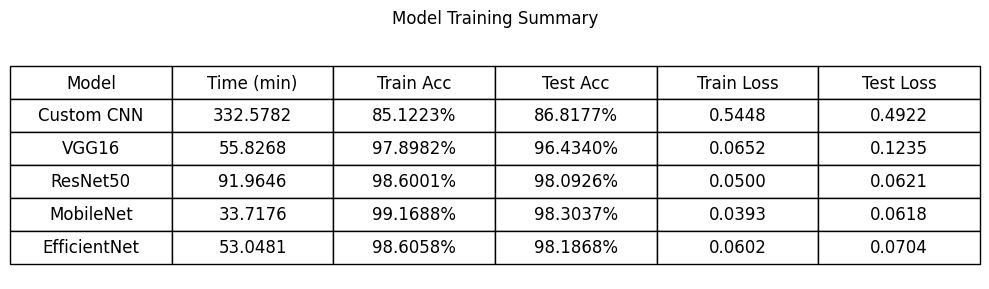

In [ ]:
import matplotlib.pyplot as plt

model_names = ['Custom CNN', 'VGG16', 'ResNet50', 'MobileNet', 'EfficientNet']
training_times = [customCNN_time, VGG_time, resnet_time, mobilenet_time, efficientnet_time]
training_times_minutes = [t / 60 for t in training_times]

best_val_losses = [
    min(val_losses),
    min(vgg_val_loss),
    min(resnet_val_loss),
    min(mobilenet_val_loss),
    min(efficientnet_val_loss)
]

best_val_accs = [
    max(val_accuracys),
    max(vgg_val_accs),
    max(resnet_val_accs),
    max(mobilenet_val_accs),
    max(efficientnet_val_accs)
]

best_train_losses = [
    min(train_loss),
    min(vgg_train_loss),
    min(resnet_train_loss),
    min(mobilenet_train_loss),
    min(efficientnet_train_loss)
]

best_train_accs = [
    max(train_accuracies),
    max(vgg_train_accs),
    max(resnet_train_accs),
    max(mobilenet_train_accs),
    max(efficientnet_train_accs)
]

test_accs = [
    test_accuracy,
    vgg_test_acc,
    resnet_test_acc,
    mobilenet_test_acc,
    efficientnet_test_acc,
]

test_losses = [
    avg_test_loss,
    vgg_test_loss,
    resnet_test_loss,
    mobilenet_test_loss,
    efficientnet_test_loss,
]

precisions = [custom_precision ,vgg_precision, resnet_precision, mobilenet_precision, efficientnet_precision]
recalls = [custom_recall, vgg_recall, resnet_recall, mobilenet_recall, efficientnet_recall]
f1_scores = [custom_f1_score, vgg_f1_score, resnet_f1_score, mobilenet_f1_score, efficientnet_f1_score]

table_data = list(zip(
    model_names,
    [f"{t:.4f}" for t in training_times_minutes],
    [f"{acc:.4f}%" for acc in best_train_accs],
    [f"{acc:.4f}%" for acc in test_accs],
    [f"{loss:.4f}" for loss in best_train_losses],
    [f"{loss:.4f}" for loss in test_losses],
))

column_labels = ['Model', 'Time (min)', 'Train Acc', 'Test Acc', 'Train Loss', 'Test Loss']

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(cellText=table_data,
                 colLabels=column_labels,
                 cellLoc='center',
                 loc='center')

table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(12)

plt.title('Model Training Summary', pad=20)
plt.tight_layout()
plt.show()


# **Prediction**
In this section, you can upload your images to get predictions.

Here, it defines five different deep learning model architectures for 226 classes. This function helps to load the architecture to the model when using the saved model from the file.

In [ ]:
def build_resnet(num_classes):
    model = models.resnet50(pretrained=False)
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 1024),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(1024, 226)
    )
    return model

def build_vgg16(num_classes):
    model = models.vgg16(pretrained=False)
    model.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1024, 226)
    )
    return model

def build_mobilenet(num_classes):
    model = models.mobilenet_v3_large(pretrained=False)
    model.classifier = nn.Sequential(
        nn.Linear(model.classifier[0].in_features, 1024),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(1024, 226)
    )
    return model

def build_efficientnet(num_classes):
    model = models.efficientnet_b0(pretrained=False)
    model.classifier = nn.Sequential(
        nn.Linear(model.classifier[1].in_features, 1024),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(1024, 226)
    )
    return model

class CNN(nn.Module):
    def __init__(self,num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 12 * 12, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)

        return x

This script performs plant species prediction on a set of images using five different deep learning models: a custom CNN and four transfer learning models (VGG16, ResNet50, MobileNetV3, and EfficientNetB0). It loads the class labels from the training dataset. It prepares two different image preprocessing pipelines, one for the custom CNN (resizing to 100x100) and another for the transfer learning models (resizing to 224x224). Each image in the predictions folder is loaded and passed through each model. The custom CNN model is loaded entirely from a saved .pth file, while the others are reconstructed using their respective builder functions before loading their pretrained weights. The script then runs each model in evaluation mode, computes the prediction using softmax to get class probabilities, and prints the predicted plant name and the model's confidence score for each image.

You must create a folder called predictions and put all the images into it. Also you should upload saved model files as well.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from PIL import Image
import os
import warnings
warnings.filterwarnings("ignore")


dataset = datasets.ImageFolder('Dataset/Training')

class_names = dataset.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

transform_custom = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

models_info = {
    "Custom CNN": ("plant_model.pth", None),
    "VGG16": ("best_vgg16_model.pth", build_vgg16),
    "ResNet50": ("best_resnet50_model.pth", build_resnet),
    "MobileNet": ("best_mobilenetv3_model.pth", build_mobilenet),
    "EfficientNet": ("best_efficientnet_model.pth", build_efficientnet),
}

pred_dir = 'predictions'
image_files = [f for f in os.listdir(pred_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.webp'))]

print("Predictions:")
print("----------------------------------------------------------------")
for image_file in image_files:
  img_path = os.path.join(pred_dir, image_file)
  image = Image.open(img_path).convert('RGB')
  print(f"Image: {image_file}")
  for model_name, (file_name, builder_fn) in models_info.items():
      if model_name == "Custom CNN":
          model = torch.load(file_name, map_location=device, weights_only=False)
          input_tensor = transform_custom(image).unsqueeze(0).to(device)
      else:
          model = builder_fn(len(class_names))
          model.load_state_dict(torch.load(file_name, map_location=device))
          input_tensor = transform(image).unsqueeze(0).to(device)
      model.to(device)
      model.eval()

      with torch.no_grad():
          outputs = model(input_tensor)
          probabilities = torch.softmax(outputs, dim=1)
          confidence, pred = torch.max(probabilities, 1)
          class_idx = pred.item()
          plant_name = class_names[class_idx]
          confidence_score = confidence.item() * 100

      print(f"{model_name}: {plant_name} ({confidence_score:.2f}% confidence)")
  print("----------------------------------------------------------------")


Predictions:
----------------------------------------------------------------
Image: bean.JPG
Custom CNN: Kale (81.34% confidence)
VGG16: Longbeans (56.25% confidence)
ResNet50: Aloevera (99.30% confidence)
MobileNet: Bean (39.52% confidence)
EfficientNet: Bean (61.78% confidence)
----------------------------------------------------------------
Image: avacado.jpg
Custom CNN: Cucumber (20.44% confidence)
VGG16: Pumpkin (91.80% confidence)
ResNet50: Pumpkin (54.71% confidence)
MobileNet: Cucumber (43.01% confidence)
EfficientNet: Pumpkin (91.88% confidence)
----------------------------------------------------------------
Image: banana.webp
Custom CNN: Tobacco (30.80% confidence)
VGG16: Radish (51.05% confidence)
ResNet50: Banana (100.00% confidence)
MobileNet: Banana (100.00% confidence)
EfficientNet: Banana (99.99% confidence)
----------------------------------------------------------------
Image: blueberry.webp
Custom CNN: Orchid (75.53% confidence)
VGG16: Potato (91.93% confidence)
Re